(Subdomain-ADR)=
# Subdomains ADR

We demonstrate here how to solve general bulk or surface ADR equation on different domain parts.

Let's start by creating a geometry with two subdomains

In [10]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *   # Opencascade for geometry modeling

outer = Rectangle(2, 2).Face()
outer.edges.name="outer"
outer.edges.Max(X).name = "r"
outer.edges.Min(X).name = "l"
outer.edges.Min(Y).name = "b"
outer.edges.Max(Y).name = "t"

inner = MoveTo(0.5, 0.5).Rectangle(1, 1).Face()
inner.edges.name="interface"
outer = outer - inner

inner.faces.name="inner"
inner.faces.col = (1, 0, 0)
outer.faces.name="outer"

geo = Glue([inner, outer])
Draw(geo);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …

Let's now mesh it

In [11]:
mesh = Mesh(OCCGeometry(geo, dim=2).GenerateMesh(maxh=0.1))
Draw(mesh);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Let's initialize the simulation with the respective time parameters

In [12]:
from cosmos.solvers.simulation import UnsteadyProblem

dt = Parameter(0.05)
T = 1.0
t = Parameter(0)
simulation = UnsteadyProblem(mesh=mesh, t=t, dt = dt, T = T, verbose = 2)

------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  510
     edges is:  1447
     faces is:  938
     facets is:  1447
     elements is:  938 ( = 0 if hypersurface)
Regions of co-dimension  0 :
  - There is(are)  1 region(s) called  inner
  - There is(are)  1 region(s) called  outer
Regions of co-dimension  1 :
  - There is(are)  4 region(s) called  interface
  - There is(are)  1 region(s) called  b
  - There is(are)  1 region(s) called  l
  - There is(are)  1 region(s) called  r
  - There is(are)  1 region(s) called  t
Regions of co-dimension  2 :
  - There is(are)  8 region(s) called  default
------------------------------------------------------------ 



Let's create the solver.  \
This is done using the `ADRSolver` class of the `cosmos` package. \
The solver has then to be added to the simulation in order to access the time variables and the mesh information

In [13]:
from cosmos.solvers.adr import ADRSolver
solver = ADRSolver()
simulation.attach_solver(solver)

------------------------------------------------------------
This is a solver for a coupled Bulk-Surface Advection-Diffusion-Reaction problem
It uses conforming H-1 elements of order  1
Its parameters are
  - linear - with type  <class 'bool'>
------------------------------------------------------------ 



At this point we need to prescribe the coefficients of our ADR equations. Note that in the internal domain the normal is the one of the inner circle, so we need to adjust the boundary conditions accordingly. \
We create manufactured solutions for both so that later we can use it to perform convergence studies

In [14]:
from cosmos.utils.manufactured_solution_tools import gradient

# Solver 1
u_ex1 = cos(pi*x)*sin(pi*y)*cos(t)
d1 = 1 + x**2
c1 = 1 + x**2
b1 = CF((sin(x), 1))
flux1 = b1*u_ex1 - d1*gradient(u_ex1, Id(2))
rhs1 = (u_ex1.Diff(t) + Trace(gradient(flux1, Id(2))) + c1*u_ex1).Compile()
dir_d1 = {'interface': u_ex1}
dir_b1 = {'interface': u_ex1}
neu_b1 = {'interface|r|l|b|t': b1*u_ex1}
neu_d1 = {'interface|r|l|b|t': - d1*gradient(u_ex1, Id(2))}
solver.AddSpecie(VorB = VOL,
                rhs = rhs1,
                advection = b1,
                diffusion = d1,
                reaction = c1,
                u0 = u_ex1,
                neu_d = neu_d1,
                neu_b = neu_b1,
                domain = 'inner')

# Solver 1
u_ex2 = cos(pi*x)*cos(t)
d2 = 1 + x**2
c2 = 1 + t**2
b2 = CF((0, 0))
flux2 = b2*u_ex2 - d2*gradient(u_ex2, Id(2))
rhs2 = (u_ex2.Diff(t) + Trace(gradient(flux2, Id(2))) + c2*u_ex2).Compile()
neu_b2 = {'r|l|b|t': b2*u_ex2,
              'interface': -b2*u_ex2}
neu_d2 = {'r|l|b|t': - d2*gradient(u_ex2, Id(2)),
              'interface': d2*gradient(u_ex2, Id(2))}
solver.AddSpecie(VorB = VOL,
                rhs = rhs2,
                advection = b2,
                diffusion = d2,
                reaction = c2,
                u0 = u_ex2,
                neu_b = neu_b2,
                neu_d = neu_d2,
                domain = 'outer')

We can finally run the simulation and plot the final result, comparing it with the exact solution.

In [15]:
simulation.run()

print('Computed solutions')

solver.draw_solution()

print('Exact solutions - defined everywhere')

Draw(u_ex1, mesh)
Draw(u_ex2, mesh)


Running Simulation...: 100%|███████████████| 20/20 [00:00<00:00, 32.49it/s]

Computed solutions


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solutions - defined everywhere


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

We can also compute the errors and plot them

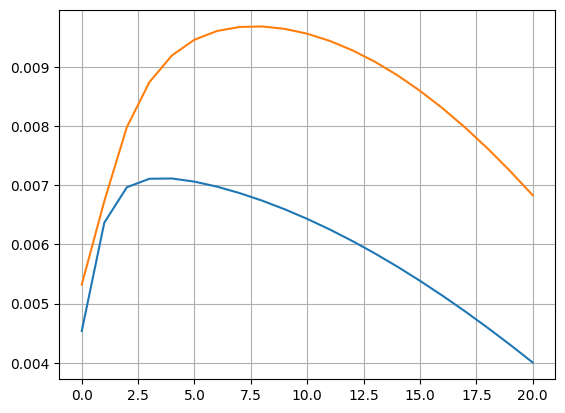

In [16]:
err = solver.compute_error([u_ex1, u_ex2], 'L2')

import matplotlib.pyplot as plt

plt.plot(err[0])
plt.plot(err[1])
plt.grid()
plt.show()

We can repeat the same procedure for a moving domain as follows

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  338
     edges is:  948
     faces is:  611
     facets is:  948
     elements is:  611 ( = 0 if hypersurface)
Regions of co-dimension  0 :
  - There is(are)  1 region(s) called  inner
  - There is(are)  1 region(s) called  outer
Regions of co-dimension  1 :
  - There is(are)  1 region(s) called  interface
  - There is(are)  1 region(s) called  outer
Regions of co-dimension  2 :
  - There is(are)  2 region(s) called  default
------------------------------------------------------------ 

------------------------------------------------------------
This is a solver for a coupled Bulk-Surface Advection-Diffusion-Reaction problem
It uses conforming H-1 elements of order  1
Its parameters are
  - linear - with type  <class 'bool'>
------------------------------------------------------------ 



Running Simulation...: 100%|███████████████| 10/10 [00:01<00:00,  7.15it/s]

Computed solutions


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

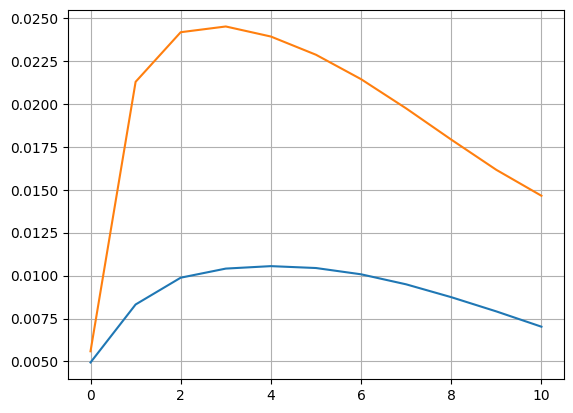

In [17]:
# %%

from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *   # Opencascade for geometry modeling

outer = Circle((0,0), 1).Face()
outer.edges.name="outer"

inner = Circle((0,0), 0.5).Face()
inner.edges.name="interface"
outer = outer - inner

inner.faces.name="inner"
inner.faces.col = (1, 0, 0)
outer.faces.name="outer"

geo = Glue([inner, outer])
Draw(geo);

mesh = Mesh(OCCGeometry(geo, dim=2).GenerateMesh(maxh=0.1))
Draw(mesh);

from cosmos.solvers.simulation import MovingProblem

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = MovingProblem(mesh=mesh, t=t, dt = dt, T = T, verbose = 2)

A = CF(((1+0.25*sin(t))*cos(t), -sin(t),\
                sin(t), (1-0.25*sin(t))*cos(t)), dims = (2,2))
B = CF((0.2*t, 0.1*t))
phi = A*CF((x,y)) + B # Deformation map
detJ = Det(A)
invA = Cof(A).trans/detJ
inv_phi = invA*(CF((x,y)) - B) # Inverse of deformation map
w_phi = A.Diff(t)*inv_phi + B.Diff(t) # velocity of the moving domain
displ_ex = phi - CF((x,y))
def displacement():
        return displ_ex
simulation.set_displacement(displacement)

solver = ADRSolver()
simulation.attach_solver(solver)


# Solver 1
u_ex1 = cos(pi*x)*sin(pi*y)*cos(t)
d1 = 1 + x**2
c1 = 1 + x**2
b1 = CF((sin(x), 1))
flux1 = b1*u_ex1 - d1*gradient(u_ex1, Id(2)) + w_phi*u_ex1
rhs1 = (u_ex1.Diff(t) + Trace(gradient(flux1, Id(2))) + c1*u_ex1).Compile()
dir_b1 = {'interface': u_ex1}
dir_d1 = {'interface': u_ex1}
neu_b1 = {'interface': b1*u_ex1}
neu_d1 = {'interface': - d1*gradient(u_ex1, Id(2))}
solver.AddSpecie(VorB = VOL,
                rhs = rhs1,
                advection = b1,
                diffusion = d1,
                reaction = c1,
                u0 = u_ex1,
                neu_d = neu_d1,
                neu_b = neu_b1,
                domain = 'inner')

# Solver 1
u_ex2 = cos(pi*x)*cos(t)
d2 = 1 + x**2
c2 = 1 + t**2
b2 = CF((sin(x), 2))
flux2 = b2*u_ex2 - d2*gradient(u_ex2, Id(2)) + w_phi*u_ex2
rhs2 = (u_ex2.Diff(t) + Trace(gradient(flux2, Id(2))) + c2*u_ex2).Compile()
dir_b2 = {'interface': u_ex2}
dir_d2 = {'interface': u_ex2}
neu_b2 = {'outer': b2*u_ex2}
neu_d2 = {'outer': - d2*gradient(u_ex2, Id(2))}
solver.AddSpecie(VorB = VOL,
                rhs = rhs2,
                advection = b2,
                diffusion = d2,
                reaction = c2,
                u0 = u_ex2,
                neu_d = neu_d2,
                neu_b = neu_b2,
                dir_d = dir_d2,
                dir_b = dir_b2,
                domain = 'outer')

simulation.run()

print('Computed solutions')

solver.draw_solution()

err = solver.compute_error([u_ex1, u_ex2], 'L2')

plt.plot(err[0])
plt.plot(err[1])
plt.grid()
plt.show()
# %%

And for a surface

Running Simulation...: 100%|███████████████| 10/10 [00:02<00:00,  4.55it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

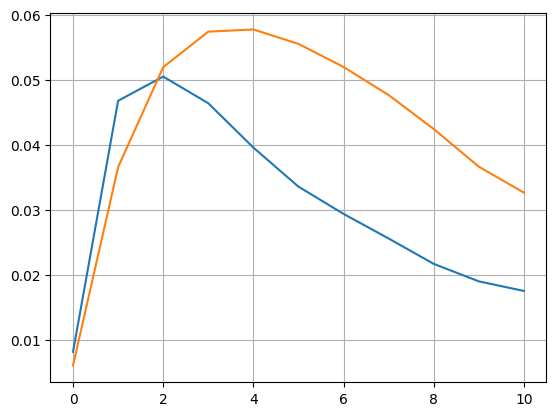

In [18]:
from netgen.csg import *
from netgen.meshing import MeshingStep

geo          = CSGeometry()
sphere       = Sphere(Pnt(0,0,0), 1)
sphere1      = Sphere(Pnt(0,0,0), 1)
bot          = Plane(Pnt(0,0,0), Vec(0,-1,0))
bot1          = Plane(Pnt(0,0,0), Vec(0,1,0))
finitesphere1 = sphere * bot
finitesphere2 = sphere1 * bot1
finitesphere1.bc('surface1')
finitesphere2.bc('surface2')

geo.AddSurface(sphere, finitesphere1)
geo.AddSurface(sphere1, finitesphere2)
geo.NameEdge(sphere,bot, "boundary")


mesh = Mesh(geo.GenerateMesh(maxh=0.1, perfstepsend=MeshingStep.MESHSURFACE))


dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = MovingProblem(mesh=mesh, t=t, dt = dt, T = T)

from cosmos.utils.manufactured_solution_tools import get_lin_trans_params

A = CF(((1+0.25*sin(t))*cos(t), -sin(t), 0,\
                sin(t), (1-0.25*sin(t))*cos(t), 0,\
                    0, 0, 1), dims = (3,3))
B = CF((0.2*t, 0.1*t, 0))
phi, inv_phi, w_phi, detJ, n_ex = get_lin_trans_params(A, B, t)
# phi, inv_phi, w_phi, detJ, n_ex = get_lin_trans_params(A, B, t)
# phi is the deformation map
# inv_phi is its inverse
# w_phi is the velocity of the domain
# n_ex is the normal to the surface
P_ex = Id(3) - OuterProduct(n_ex, n_ex)
displ_ex = phi - CF((x,y,z))

def displacement():
        return displ_ex
simulation.set_displacement(displacement)

solver = ADRSolver(linear = True)
simulation.attach_solver(solver)

u_ex1 = cos(pi*x)*sin(pi*y)*cos(t)
d1 = 1 + x**2
c1 = 1 + t**2
b1 = P_ex*CF((0,0,0))
flux_c1 = (b1*u_ex1).Compile()
flux_d1 = (- d1*gradient(u_ex1, P_ex)).Compile()
flux1 = flux_c1 + flux_d1
rel_flux1 = u_ex1*Trace(gradient(w_phi, P_ex)) + w_phi*gradient(u_ex1, Id(3))
rhs1 = (u_ex1.Diff(t) + rel_flux1 + Trace(gradient(flux1, P_ex)) + c1*u_ex1).Compile()
neu_b1 = {'boundary': flux_c1}
neu_d1 = {'boundary': flux_d1}
dir_d1 = {'boundary': u_ex1}
dir_b1 = {'boundary': u_ex1}

solver.AddSpecie(VorB = BND,
            rhs = rhs1,
            advection = b1,
            diffusion = d1,
            reaction = c1,
            u0 = u_ex1,
            dir_b = dir_b1,
            dir_d = dir_d1,
            domain = 'surface1')

u_ex2 = sin(pi*x)*cos(t)
d2 = 1 + x**2
c2 = 1 + t**2
b2 = P_ex*CF((2,1,0))
flux_c2 = (b2*u_ex2).Compile()
flux_d2 = (- d2*gradient(u_ex2, P_ex)).Compile()
flux2 = flux_c2 + flux_d2
rel_flux2 = u_ex2*Trace(gradient(w_phi, P_ex)) + w_phi*gradient(u_ex2, Id(3))
rhs2 = (u_ex2.Diff(t) + rel_flux2 + Trace(gradient(flux2, P_ex)) + c2*u_ex2).Compile()
neu_b2 = {'boundary': flux_c2}
neu_d2 = {'boundary': flux_d2}
dir_d2 = {'boundary': u_ex2}
dir_b2 = {'boundary': u_ex2}

solver.AddSpecie(VorB = BND,
            rhs = rhs2,
            advection = b2,
            diffusion = d2,
            reaction = c2,
            u0 = u_ex2,
            neu_d = neu_d2,
            neu_b = neu_b2,
            domain = 'surface2')
    
simulation.run()

print('Computed solution')
solver.draw_solution()
print('Exact solution')
mesh.SetDeformation(simulation.data['dX'])
Draw(u_ex1, mesh)
Draw(u_ex2, mesh)
mesh.UnsetDeformation()

err = solver.compute_error([u_ex1, u_ex2], 'L2')

plt.plot(err[0])
plt.plot(err[1])
plt.grid()
plt.show()